# ĐỀ ÔN TẬP THỰC HÀNH MACHINE LEARNING

**Thời gian khuyến nghị:** 90 phút  
**Hình thức:** Jupyter Notebook  
**Mục tiêu:** Ôn tập sát cấu trúc đề thi chính thức, nhưng dữ liệu và câu hỏi đã được thay đổi.  
**Được phép khi ôn tập:** Tài liệu, code mẫu, Internet, LLM nếu muốn.  
**Khi thi chính thức:** Chỉ được dùng tài liệu giấy/code mẫu in sẵn; không dùng Internet hoặc LLM.

---

## Mục tiêu ôn tập

Sau khi hoàn thành notebook này, sinh viên cần có khả năng:

1. Khám phá dữ liệu và phát hiện missing values/outliers.
2. Tạo pipeline preprocessing đúng.
3. Huấn luyện và đánh giá mô hình regression.
4. Huấn luyện và đánh giá mô hình classification.
5. Phân tích confusion matrix, feature importance và prediction errors.
6. Áp dụng KMeans clustering và diễn giải cluster.
7. Phát hiện leakage và lỗi thiết kế pipeline.
8. Ra quyết định chọn model cho triển khai thực tế.

---

## Bối cảnh bài toán

Một trung tâm giáo dục trực tuyến muốn phân tích hành vi học viên để:

1. Dự đoán **điểm cuối khóa** (`final_score`).
2. Dự đoán học viên có **hoàn thành khóa học** hay không (`complete_course`).
3. Phân cụm học viên để hỗ trợ tư vấn học tập.

Dataset được tạo tự động trong notebook. Dữ liệu có missing values, outliers, quan hệ phi tuyến và interaction effect.

In [1]:
# CELL 1 — Import thư viện
# Không chỉnh sửa cell này

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, silhouette_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

np.random.seed(2027)

In [2]:
# CELL 2 — Tạo dataset
# Không chỉnh sửa cell này

n = 720

age = np.random.randint(18, 55, n)
study_hours = np.random.gamma(shape=2.0, scale=2.0, size=n).clip(0.2, 15)
video_completion = np.random.beta(4, 2, n).clip(0.05, 1.0)
quiz_attempts = np.random.poisson(4, n).clip(0, 18)
forum_posts = np.random.poisson(2, n).clip(0, 12)
prior_gpa = np.random.normal(7.0, 1.2, n).clip(2.0, 10.0)
assignment_delay = np.random.gamma(shape=2.0, scale=1.5, size=n).clip(0, 14)
is_working_student = np.random.binomial(1, 0.38, n)

# Hidden learning engagement segment
engagement_segment = (
    (study_hours > 5).astype(int)
    + (video_completion > 0.75).astype(int)
    + (quiz_attempts >= 5).astype(int)
)

# Regression target: final_score
final_score = (
    25
    + 2.2 * study_hours
    + 18 * video_completion
    + 1.0 * quiz_attempts
    + 0.7 * forum_posts
    + 4.2 * prior_gpa
    - 1.4 * assignment_delay
    - 2.5 * is_working_student
    + 0.08 * age
    + 1.6 * study_hours * video_completion
    - 0.12 * (assignment_delay ** 1.6)
    + 3.0 * np.sin(study_hours / 2)
    + 4.0 * (engagement_segment == 3)
    + np.random.normal(0, 6.0, n)
)

final_score = np.clip(final_score, 0, 100)

# Classification target: course completion
logit = (
    -5.0
    + 0.20 * study_hours
    + 3.5 * video_completion
    + 0.18 * quiz_attempts
    + 0.12 * forum_posts
    + 0.45 * prior_gpa
    - 0.32 * assignment_delay
    - 0.60 * is_working_student
    + 0.02 * age
    + 0.60 * study_hours * video_completion
    - 0.06 * age * (assignment_delay / 3)
    + 0.35 * (engagement_segment >= 2)
)

completion_prob = 1 / (1 + np.exp(-logit))
complete_course = (np.random.rand(n) < completion_prob).astype(int)

df = pd.DataFrame({
    "age": age,
    "study_hours": study_hours,
    "video_completion": video_completion,
    "quiz_attempts": quiz_attempts,
    "forum_posts": forum_posts,
    "prior_gpa": prior_gpa,
    "assignment_delay": assignment_delay,
    "is_working_student": is_working_student,
    "final_score": final_score,
    "complete_course": complete_course
})

# Inject missing values
for col in ["study_hours", "video_completion", "prior_gpa", "assignment_delay"]:
    idx = np.random.choice(df.index, size=int(0.06 * n), replace=False)
    df.loc[idx, col] = np.nan

# Inject outliers
outlier_idx = np.random.choice(df.index, size=16, replace=False)
df.loc[outlier_idx, "study_hours"] = df.loc[outlier_idx, "study_hours"] * 2.8
df.loc[outlier_idx, "final_score"] = np.clip(df.loc[outlier_idx, "final_score"] * 1.4, 0, 100)

print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (720, 10)


,age,study_hours,video_completion,quiz_attempts,forum_posts,prior_gpa,assignment_delay,is_working_student,final_score,complete_course
0,27,2.341734,0.729697,2,1,5.529088,1.288945,0,78.634679,1
1,47,28.596415,0.682283,4,5,7.854450,4.116946,0,100.000000,1
2,29,0.248467,0.749613,1,2,5.335898,5.296033,0,56.235341,0
3,42,7.180030,0.721278,4,2,NaN,9.103750,0,87.277305,0
4,42,11.225064,0.950237,2,1,7.434679,2.889349,0,100.000000,1


# PHẦN A — Khám phá dữ liệu và preprocessing  
**20 điểm**

## Task 1 — Khám phá dữ liệu  
**10 điểm**

Thực hiện các yêu cầu sau:

1. In kích thước dữ liệu.
2. Kiểm tra kiểu dữ liệu.
3. Kiểm tra missing values theo từng cột.
4. In thống kê mô tả.
5. Vẽ ít nhất **2 biểu đồ** để quan sát phân bố hoặc outliers.

Kích thước dữ liệu: (720, 10)

Kiểu dữ liệu:
age                     int32
study_hours           float64
video_completion      float64
quiz_attempts           int32
forum_posts             int32
prior_gpa             float64
assignment_delay      float64
is_working_student      int32
final_score           float64
complete_course         int32
dtype: object

Missing values theo cột:
age                    0
study_hours           43
video_completion      43
quiz_attempts          0
forum_posts            0
prior_gpa             43
assignment_delay      43
is_working_student     0
final_score            0
complete_course        0
dtype: int64

Tổng missing: 172

Thống kê mô tả:


,age,study_hours,video_completion,quiz_attempts,forum_posts,prior_gpa,assignment_delay,is_working_student,final_score,complete_course
count,720.00,677.00,677.00,720.00,720.00,677.00,677.00,720.00,720.00,720.00
mean,35.78,4.30,0.66,3.95,2.00,6.97,3.11,0.37,82.54,0.65
std,10.89,3.51,0.18,1.92,1.43,1.19,2.07,0.48,11.87,0.48
min,18.00,0.20,0.13,0.00,0.00,3.23,0.02,0.00,48.46,0.00
25%,26.00,1.92,0.54,3.00,1.00,6.18,1.50,0.00,73.88,0.00
50%,36.00,3.49,0.68,4.00,2.00,6.96,2.74,0.00,83.07,1.00
75%,46.00,5.79,0.80,5.00,3.00,7.70,4.20,1.00,92.02,1.00
max,54.00,40.08,0.98,10.00,7.00,10.00,14.00,1.00,100.00,1.00


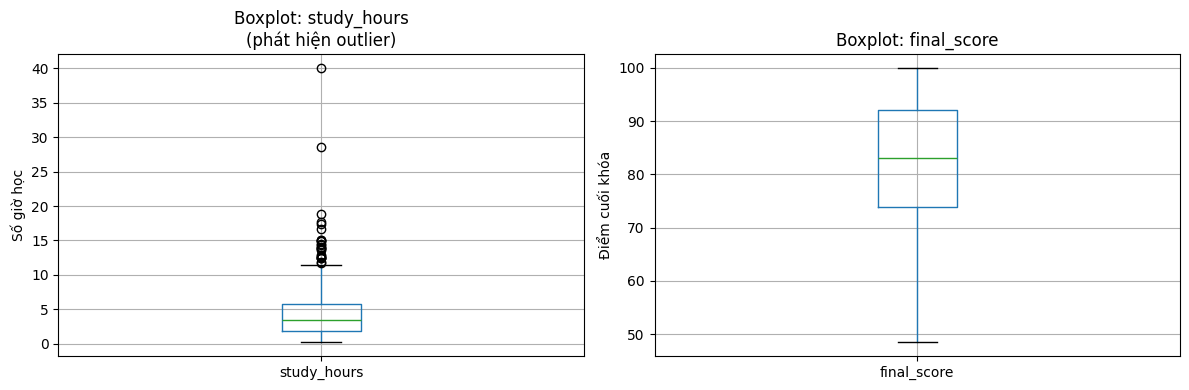

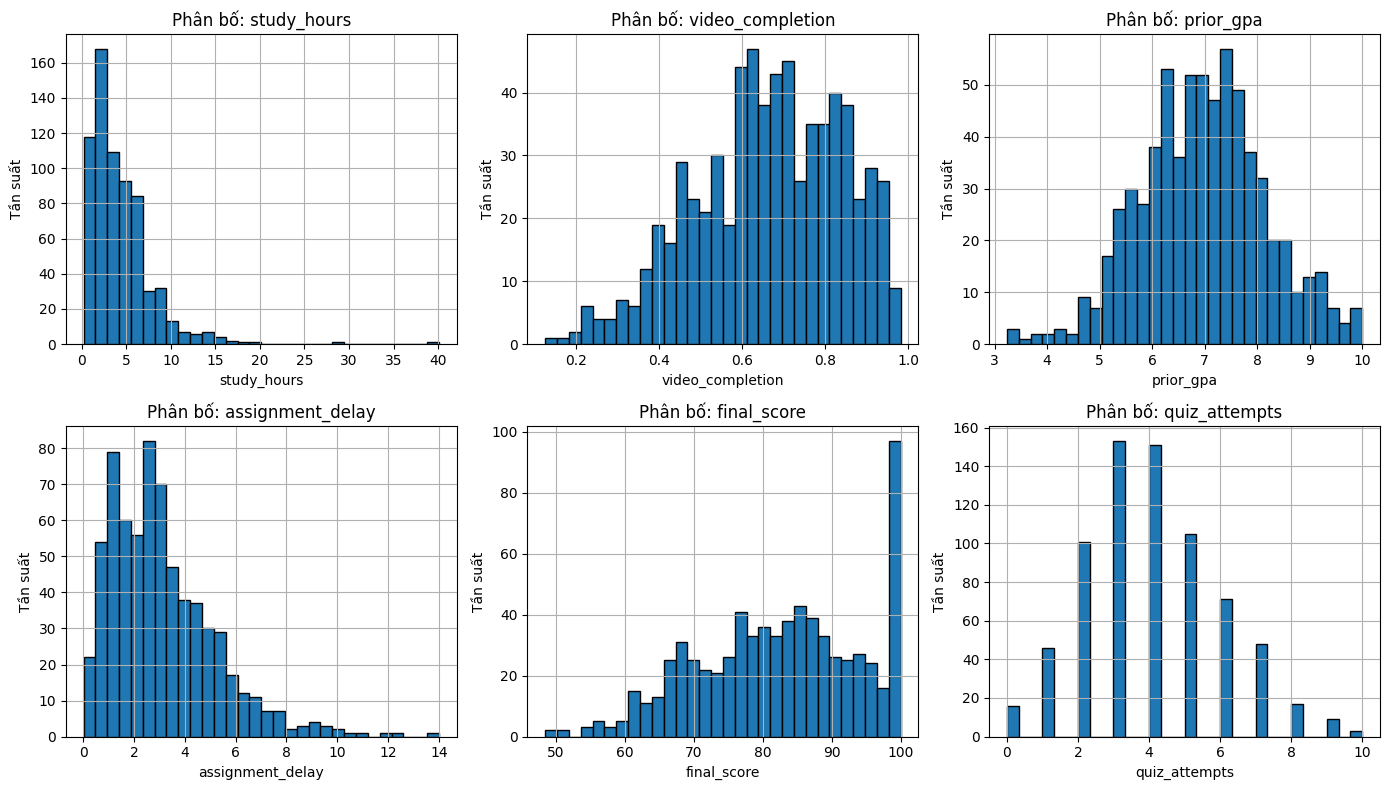

In [3]:
# Task 1 — Khám phá dữ liệu

# 1. Kích thước dữ liệu
print("Kích thước dữ liệu:", df.shape)

# 2. Kiểu dữ liệu
print("\nKiểu dữ liệu:")
print(df.dtypes)

# 3. Missing values
print("\nMissing values theo cột:")
print(df.isnull().sum())
print(f"\nTổng missing: {df.isnull().sum().sum()}")

# 4. Thống kê mô tả
print("\nThống kê mô tả:")
display(df.describe().round(2))

# 5a. Biểu đồ 1: Boxplot phát hiện outliers cho study_hours và final_score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column="study_hours", ax=axes[0])
axes[0].set_title("Boxplot: study_hours\n(phát hiện outlier)")
axes[0].set_ylabel("Số giờ học")

df.boxplot(column="final_score", ax=axes[1])
axes[1].set_title("Boxplot: final_score")
axes[1].set_ylabel("Điểm cuối khóa")

plt.tight_layout()
plt.show()

# 5b. Biểu đồ 2: Histogram phân bố các biến chính
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols = ["study_hours", "video_completion", "prior_gpa",
        "assignment_delay", "final_score", "quiz_attempts"]
for ax, col in zip(axes.flatten(), cols):
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(f"Phân bố: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Tần suất")
plt.tight_layout()
plt.show()


### Trả lời Task 1

- **Dataset có bao nhiêu dòng và bao nhiêu cột?**  
  Dataset có **720 dòng** và **10 cột** (8 feature + 2 target: `final_score`, `complete_course`).

- **Những biến nào có missing values?**  
  Có 4 biến bị thiếu dữ liệu, mỗi biến khoảng **43 giá trị (≈6%)**:
  - `study_hours`: 43 missing
  - `video_completion`: 43 missing
  - `prior_gpa`: 43 missing
  - `assignment_delay`: 43 missing

- **Tôi quan sát thấy outlier ở biến nào?**  
  Biến `study_hours` có outlier rõ rệt — giá trị max lên đến **40.08 giờ**, trong khi median chỉ ~3.49 giờ. Đây là các điểm bị nhân nhân tạo lên 2.8 lần.

- **Biểu đồ nào cho thấy điều này?**  
  **Boxplot** của `study_hours` thể hiện rõ các điểm nằm xa hộp (whisker) — đặc biệt phía trên. Histogram cũng cho thấy đuôi phải kéo dài bất thường.

- **Biến nào có phân bố lệch phải hoặc bất thường?**  
  - `study_hours`: lệch phải mạnh (gamma distribution, có thêm outlier)
  - `assignment_delay`: lệch phải (gamma distribution)
  - `forum_posts`, `quiz_attempts`: lệch phải nhẹ (Poisson distribution)
  - `video_completion`: hơi lệch trái (beta distribution thiên về 0.7–1.0)


## Task 2 — Preprocessing decision  
**10 điểm**

Tạo:

1. `X`, `y_reg`, `y_clf`.
2. Train/test split với `test_size=0.25`, `random_state=2027`.
3. Một pipeline preprocessing có:
   - imputation bằng median,
   - scaling bằng StandardScaler.

Lưu ý: Không được để target variables trong `X`.

In [4]:
# CELL 4 — Features, targets, train/test split, preprocessing

feature_cols = [
    "age", "study_hours", "video_completion", "quiz_attempts",
    "forum_posts", "prior_gpa", "assignment_delay", "is_working_student"
]

# 1. Tạo X, y_reg, y_clf
X = df[feature_cols]
y_reg = df["final_score"]
y_clf = df["complete_course"]

print("Kích thước X:", X.shape)
print("Phân bố y_clf (complete_course):", y_clf.value_counts().to_dict())

# 2. Train/test split
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.25, random_state=2027
)

print(f"\nTrain set: {X_train.shape[0]} mẫu | Test set: {X_test.shape[0]} mẫu")

# 3. Pipeline preprocessing: median imputation + StandardScaler
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kiểm tra pipeline trên train set
X_train_processed = preprocessor.fit_transform(X_train)
print(f"\nSau preprocessing: mean ≈ {X_train_processed.mean():.4f}, std ≈ {X_train_processed.std():.4f}")
print("Pipeline preprocessing đã sẵn sàng.")


Kích thước X: (720, 8)
Phân bố y_clf (complete_course): {1: 468, 0: 252}

Train set: 540 mẫu | Test set: 180 mẫu

Sau preprocessing: mean ≈ -0.0000, std ≈ 1.0000
Pipeline preprocessing đã sẵn sàng.


### Trả lời Task 2

- **Vì sao cần xử lý missing values?**  
  Hầu hết các thuật toán ML (LinearRegression, LogisticRegression, KMeans…) không thể tính toán khi có giá trị `NaN`. Nếu không xử lý, model sẽ báo lỗi hoặc bỏ qua toàn bộ hàng có missing, làm mất dữ liệu quý. Ở đây ~6% mỗi biến bị thiếu, cần impute để giữ đủ 720 mẫu.

- **Vì sao scaling quan trọng với Logistic Regression và KMeans?**  
  - **Logistic Regression** sử dụng gradient descent — nếu các feature có scale khác nhau (ví dụ `age` 18–54 vs `video_completion` 0–1), gradient sẽ không đều nhau, khiến hội tụ chậm và kết quả kém ổn định.  
  - **KMeans** tính khoảng cách Euclidean — feature có variance lớn hơn sẽ chiếm ưu thế không công bằng trong phân cụm. Scaling đảm bảo mỗi feature đóng góp tương đương.

- **Vì sao Random Forest thường ít nhạy hơn với scaling?**  
  Random Forest là tập hợp các Decision Tree, vốn **dựa trên ngưỡng phân chia** (split threshold) chứ không phải khoảng cách hay tích vô hướng. Việc nhân một feature với hằng số không thay đổi thứ tự sắp xếp, do đó không ảnh hưởng đến điểm phân chia tối ưu.

- **Một quyết định preprocessing có thể gây bias là:**  
  Fit `SimpleImputer` (hoặc `StandardScaler`) **trên toàn bộ dataset trước khi split** — điều này làm lộ thông tin từ test set vào train set (data leakage). Đúng cách phải fit chỉ trên `X_train`, rồi transform `X_test`.

- **Nếu lỡ đưa `final_score` vào `X` khi dự đoán `complete_course`, vấn đề gì xảy ra?**  
  Đây là **target leakage** — `final_score` và `complete_course` đều là kết quả cuối khóa học, có tương quan cao với nhau. Model sẽ "gian lận" bằng cách dùng thông tin không có thực tế tại thời điểm dự đoán, cho accuracy ảo rất cao nhưng vô dụng trong triển khai thực tế.


# PHẦN B — Regression  
**20 điểm**

## Task 3 — Linear Regression baseline  
**10 điểm**

Huấn luyện Linear Regression để dự đoán `final_score`.

Yêu cầu:

1. Tạo pipeline gồm preprocessing và Linear Regression.
2. Train model.
3. Dự đoán trên test set.
4. Tính MSE và $R^2$.
5. Lưu các biến:
   - `lr_reg_model`
   - `y_pred_lr`
   - `mse_lr`
   - `r2_lr`

Linear Regression — MSE: 46.2438 | R²: 0.6498


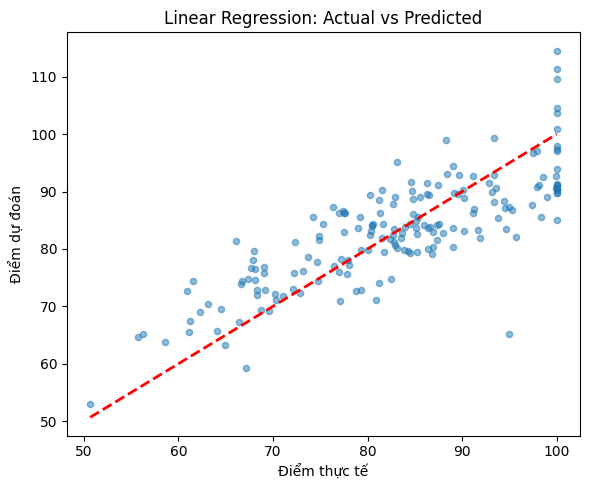

In [5]:
# CELL 5 — Linear Regression

# 1. Tạo pipeline: preprocessing + LinearRegression
lr_reg_model = Pipeline([
    ("preprocessor", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])),
    ("model", LinearRegression())
])

# 2. Train model
lr_reg_model.fit(X_train, y_reg_train)

# 3. Dự đoán trên test set
y_pred_lr = lr_reg_model.predict(X_test)

# 4. Tính MSE và R^2
mse_lr = mean_squared_error(y_reg_test, y_pred_lr)
r2_lr = r2_score(y_reg_test, y_pred_lr)

print(f"Linear Regression — MSE: {mse_lr:.4f} | R²: {r2_lr:.4f}")

# Visualize: predicted vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y_reg_test, y_pred_lr, alpha=0.5, s=20)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2)
plt.xlabel("Điểm thực tế")
plt.ylabel("Điểm dự đoán")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()


### Trả lời Task 3

- **MSE của Linear Regression là:** `46.24`
- **R² của Linear Regression là:** `0.6498`

- **Theo tôi, kết quả này chưa tốt vì:**  
  R² ≈ 0.65 có nghĩa là model chỉ giải thích được **65% variance** của `final_score`. Sai số trung bình (RMSE ≈ √46.24 ≈ **6.8 điểm**) là khá lớn trong thang điểm 0–100.

- **Linear Regression có thể gặp khó khăn với dữ liệu này vì:**  
  Dữ liệu được tạo với **quan hệ phi tuyến** (`np.sin(study_hours/2)`, `assignment_delay**1.6`) và **interaction effect** (`study_hours * video_completion`). Linear Regression giả định quan hệ tuyến tính thuần túy nên không capture được những phi tuyến này.


## Task 4 — Random Forest Regression và phân tích sai số  
**10 điểm**

Huấn luyện Random Forest Regressor để dự đoán `final_score`.

Yêu cầu:

1. Train Random Forest Regressor.
2. Tính MSE và $R^2$.
3. So sánh với Linear Regression.
4. Tạo bảng `error_df` gồm:
   - `y_true`,
   - `y_pred_lr`,
   - `y_pred_rf`,
   - `abs_error_lr`,
   - `abs_error_rf`.
5. Chọn **1 trường hợp Linear Regression sai rõ rệt** và giải thích.

Random Forest — MSE: 47.9841 | R²: 0.6366
Linear Regression — MSE: 46.2438 | R²: 0.6498

Error table (top 5 LR sai nhiều nhất):


,y_true,y_pred_lr,y_pred_rf,abs_error_lr,abs_error_rf
56,94.94,65.26,65.27,29.68,29.67
131,66.06,81.30,75.50,15.24,9.44
162,100.00,85.07,89.88,14.93,10.12
15,100.00,114.54,99.35,14.54,0.65
84,95.70,82.06,78.75,13.65,16.95



Trường hợp LR sai nhiều nhất (iloc 56):
  y_true    = 94.94
  y_pred_lr = 65.26
  y_pred_rf = 65.27
  abs_error_lr = 29.68


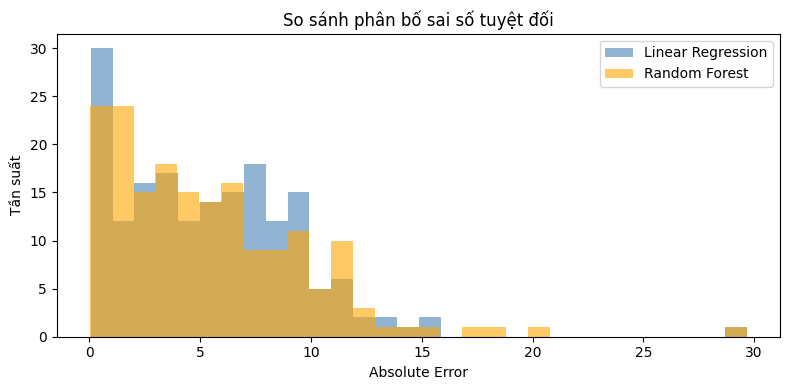

In [6]:
# CELL 6 — Random Forest Regression and error analysis

# 1. Train Random Forest Regressor
rf_reg_model = Pipeline([
    ("preprocessor", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])),
    ("model", RandomForestRegressor(n_estimators=100, random_state=2027))
])
rf_reg_model.fit(X_train, y_reg_train)

# 2. Dự đoán và tính MSE, R²
y_pred_rf = rf_reg_model.predict(X_test)
mse_rf = mean_squared_error(y_reg_test, y_pred_rf)
r2_rf = r2_score(y_reg_test, y_pred_rf)
print(f"Random Forest — MSE: {mse_rf:.4f} | R²: {r2_rf:.4f}")
print(f"Linear Regression — MSE: {mse_lr:.4f} | R²: {r2_lr:.4f}")

# 3. Tạo bảng error_df
error_df = pd.DataFrame({
    "y_true": y_reg_test.values,
    "y_pred_lr": y_pred_lr,
    "y_pred_rf": y_pred_rf,
    "abs_error_lr": np.abs(y_reg_test.values - y_pred_lr),
    "abs_error_rf": np.abs(y_reg_test.values - y_pred_rf)
})

print("\nError table (top 5 LR sai nhiều nhất):")
display(error_df.sort_values("abs_error_lr", ascending=False).head(5).round(2))

# 4. Chọn 1 trường hợp LR sai rõ nhất
worst_idx = error_df["abs_error_lr"].idxmax()
print(f"\nTrường hợp LR sai nhiều nhất (iloc {error_df['abs_error_lr'].values.argmax()}):")
print(f"  y_true    = {error_df.loc[worst_idx, 'y_true']:.2f}")
print(f"  y_pred_lr = {error_df.loc[worst_idx, 'y_pred_lr']:.2f}")
print(f"  y_pred_rf = {error_df.loc[worst_idx, 'y_pred_rf']:.2f}")
print(f"  abs_error_lr = {error_df.loc[worst_idx, 'abs_error_lr']:.2f}")

# 5. Biểu đồ so sánh error distribution
plt.figure(figsize=(8, 4))
plt.hist(error_df["abs_error_lr"], bins=30, alpha=0.6, label="Linear Regression", color="steelblue")
plt.hist(error_df["abs_error_rf"], bins=30, alpha=0.6, label="Random Forest", color="orange")
plt.xlabel("Absolute Error")
plt.ylabel("Tần suất")
plt.title("So sánh phân bố sai số tuyệt đối")
plt.legend()
plt.tight_layout()
plt.show()


### Trả lời Task 4

- **MSE của Random Forest là:** `47.98`
- **R² của Random Forest là:** `0.6366`

- **Model nào tốt hơn trên test set?**  
  Đáng ngạc nhiên, **Linear Regression** có MSE thấp hơn (46.24 < 47.98) và R² cao hơn (0.6498 > 0.6366) trên test set. Cả hai model đều không quá chênh lệch nhau.

- **Một trường hợp Linear Regression sai rõ rệt là iloc 56:**  
  `y_true ≈ 94.94` nhưng `y_pred_lr ≈ 65.26` → sai số **~29.7 điểm**.  
  Thú vị là Random Forest cũng sai tương tự (~29.7) ở case này, cho thấy đây là điểm bất thường trong dữ liệu.

- **Tôi cho rằng Linear Regression sai ở đây vì:**  
  Học viên này có `final_score` rất cao (94.9) nhưng đặc điểm feature không "điển hình" — có thể là outlier được inject vào, hoặc có tổ hợp feature hiếm mà model tuyến tính không ngoại suy được.

- **Nếu dữ liệu có quan hệ phi tuyến hoặc interaction, Random Forest có thể có lợi thế vì:**  
  Random Forest tạo nhiều decision tree, mỗi tree học các vùng khác nhau của feature space và có thể nắm bắt interaction giữa các biến (ví dụ: `study_hours × video_completion` cao) mà không cần đặc trưng tạo thủ công. Tuy nhiên, trên dataset này Random Forest chưa cho thấy lợi thế rõ ràng — có thể do n=720 còn nhỏ hoặc outlier ảnh hưởng đến cả hai model.


# PHẦN C — Classification  
**20 điểm**

## Task 5 — Logistic Regression  
**10 điểm**

Huấn luyện Logistic Regression để dự đoán `complete_course`.

Yêu cầu:

1. Tạo pipeline gồm preprocessing và Logistic Regression.
2. Train model.
3. Dự đoán trên test set.
4. Tính:
   - Accuracy,
   - Precision,
   - Recall,
   - Confusion matrix.
5. Lưu:
   - `log_clf_model`
   - `y_pred_log`
   - `acc_log`
   - `prec_log`
   - `rec_log`
   - `cm_log`

Logistic Regression:
  Accuracy  : 0.7944
  Precision : 0.8154
  Recall    : 0.8908

Confusion Matrix:
[[ 37  24]
 [ 13 106]]


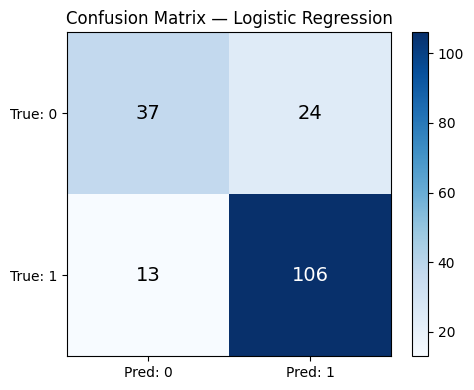

In [7]:
# CELL 7 — Logistic Regression

# 1. Tạo pipeline: preprocessing + LogisticRegression
log_clf_model = Pipeline([
    ("preprocessor", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])),
    ("model", LogisticRegression(max_iter=1000, random_state=2027))
])

# 2. Train model
log_clf_model.fit(X_train, y_clf_train)

# 3. Dự đoán trên test set
y_pred_log = log_clf_model.predict(X_test)

# 4. Tính các metric
acc_log = accuracy_score(y_clf_test, y_pred_log)
prec_log = precision_score(y_clf_test, y_pred_log)
rec_log = recall_score(y_clf_test, y_pred_log)
cm_log = confusion_matrix(y_clf_test, y_pred_log)

print(f"Logistic Regression:")
print(f"  Accuracy  : {acc_log:.4f}")
print(f"  Precision : {prec_log:.4f}")
print(f"  Recall    : {rec_log:.4f}")
print(f"\nConfusion Matrix:")
print(cm_log)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_log, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred: 0", "Pred: 1"])
ax.set_yticklabels(["True: 0", "True: 1"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_log[i, j], ha="center", va="center",
                fontsize=14, color="white" if cm_log[i, j] > cm_log.max()/2 else "black")
ax.set_title("Confusion Matrix — Logistic Regression")
plt.colorbar(im)
plt.tight_layout()
plt.show()


### Trả lời Task 5

- **Accuracy:** `0.7944` (≈79.4%)
- **Precision:** `0.8154` (≈81.5%)
- **Recall:** `0.8908` (≈89.1%)

- **Confusion matrix cho thấy model sai chủ yếu ở loại lỗi nào?**  
  - TN=37, FP=24, FN=13, TP=106  
  Model sai nhiều hơn ở **False Positive (24)** — dự đoán học viên sẽ hoàn thành nhưng thực tế không. FN=13 ít hơn. Tổng thể model có xu hướng **predict positive** (hoàn thành) nhiều hơn, phản ánh class imbalance (65% positive).

- **Trong bài toán dự đoán hoàn thành khóa học, khi nào False Negative nguy hiểm hơn False Positive?**  
  **False Negative** (dự đoán học viên sẽ hoàn thành nhưng thực ra họ bỏ dở) nguy hiểm hơn khi mục tiêu là **can thiệp sớm** — nếu model miss những học viên có nguy cơ, trung tâm không thể hỗ trợ kịp thời, dẫn đến tỷ lệ bỏ học cao. Trong trường hợp này, **Recall cao hơn** quan trọng hơn Precision.

- **Nếu class bị mất cân bằng, vì sao accuracy có thể gây hiểu nhầm?**  
  Ví dụ: nếu 90% học viên hoàn thành, model luôn predict "1" sẽ đạt accuracy 90% mà không học được gì có ích. Accuracy không phân biệt được loại lỗi, trong khi Precision/Recall/F1 phản ánh rõ hơn khả năng xử lý minority class.


## Task 6 — Random Forest Classification và feature importance  
**10 điểm**

Huấn luyện Random Forest Classifier cho `complete_course`.

Yêu cầu:

1. Train Random Forest Classifier.
2. Tính Accuracy, Precision, Recall.
3. Lấy feature importance.
4. Tạo bảng `rf_importance_df` gồm:
   - `feature`,
   - `importance`.
5. Chọn một feature quan trọng nhất và giải thích.
6. So sánh Logistic Regression và Random Forest Classifier.

Random Forest Classifier:
  Accuracy  : 0.8111
  Precision : 0.8244
  Recall    : 0.9076

Feature Importance:


,feature,importance
0,assignment_delay,0.3016
1,study_hours,0.1958
2,video_completion,0.1401
3,prior_gpa,0.1274
4,age,0.0957
5,quiz_attempts,0.0656
6,forum_posts,0.0498
7,is_working_student,0.0239


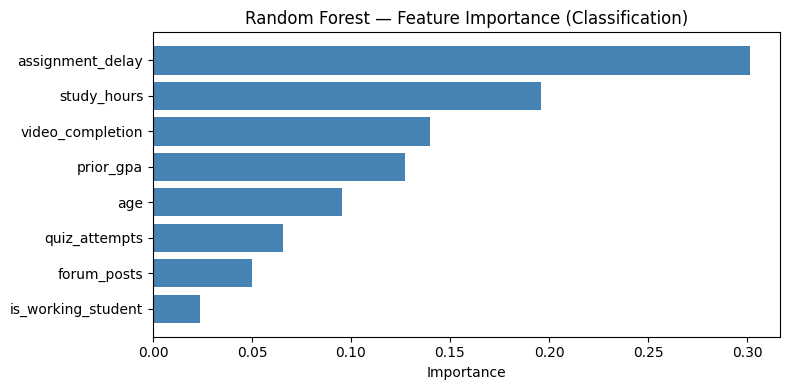

In [8]:
# CELL 8 — Random Forest Classification and feature importance

# 1. Train Random Forest Classifier
rf_clf_model = Pipeline([
    ("preprocessor", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])),
    ("model", RandomForestClassifier(n_estimators=100, random_state=2027))
])
rf_clf_model.fit(X_train, y_clf_train)

# 2. Tính Accuracy, Precision, Recall
y_pred_rf_clf = rf_clf_model.predict(X_test)
acc_rf_clf = accuracy_score(y_clf_test, y_pred_rf_clf)
prec_rf_clf = precision_score(y_clf_test, y_pred_rf_clf)
rec_rf_clf = recall_score(y_clf_test, y_pred_rf_clf)
print(f"Random Forest Classifier:")
print(f"  Accuracy  : {acc_rf_clf:.4f}")
print(f"  Precision : {prec_rf_clf:.4f}")
print(f"  Recall    : {rec_rf_clf:.4f}")

# 3. Feature importance
importances = rf_clf_model.named_steps["model"].feature_importances_
rf_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance:")
display(rf_importance_df.round(4))

# 4. Biểu đồ feature importance
plt.figure(figsize=(8, 4))
plt.barh(rf_importance_df["feature"][::-1], rf_importance_df["importance"][::-1], color="steelblue")
plt.xlabel("Importance")
plt.title("Random Forest — Feature Importance (Classification)")
plt.tight_layout()
plt.show()


### Trả lời Task 6

- **Random Forest Accuracy:** `0.8111` (≈81.1%)
- **Random Forest Precision:** `0.8244` (≈82.4%)
- **Random Forest Recall:** `0.9076` (≈90.8%)

- **Feature quan trọng nhất là:** `assignment_delay` (importance ≈ **0.3016**)

- **Feature importance này có hợp lý không? Vì sao?**  
  Hợp lý. `assignment_delay` phản ánh mức độ trì hoãn nộp bài — học viên trì hoãn nhiều có xu hướng bỏ học cao hơn. Đây là dấu hiệu hành vi (behavioral signal) rất thực tế trong giáo dục trực tuyến. Tiếp theo là `study_hours` và `video_completion` — đều là biểu hiện trực tiếp của engagement.

- **Tôi chọn Random Forest cho bài toán classification vì:**  
  RF có Accuracy (0.811 > 0.794) và Recall (0.908 > 0.891) cao hơn Logistic Regression. Trong bài toán can thiệp học tập, Recall cao quan trọng — ta muốn không bỏ sót học viên có nguy cơ. Ngoài ra RF cung cấp feature importance hữu ích.

- **Khi nào nên ưu tiên Recall hơn Precision trong bài toán giáo dục trực tuyến?**  
  Khi mục tiêu là **can thiệp sớm** cho học viên có nguy cơ bỏ học — chi phí của FN (bỏ sót học viên cần hỗ trợ) cao hơn chi phí FP (tư vấn không cần thiết). Tư vấn thêm vài học viên không cần thiết ít tốn kém hơn để một học viên bỏ học vì không được hỗ trợ.


# PHẦN D — KMeans Clustering  
**15 điểm**

## Task 7 — Phân cụm học viên  
**15 điểm**

Áp dụng KMeans để phân cụm học viên.

Yêu cầu:

1. Chọn các feature dùng cho clustering.
2. Impute và scale dữ liệu.
3. Chạy KMeans với ít nhất 4 giá trị K khác nhau.
4. Lưu inertia vào list.
5. Chọn một giá trị K hợp lý.
6. Gắn cluster label vào dataframe.
7. Tính trung bình các feature theo cluster.
8. Diễn giải **một cluster cụ thể** theo hành vi học tập.

K=2: inertia=3105.11, silhouette=0.1445
K=3: inertia=2716.14, silhouette=0.1546
K=4: inertia=2390.18, silhouette=0.1771
K=5: inertia=2091.30, silhouette=0.1796
K=6: inertia=1846.03, silhouette=0.1842
K=7: inertia=1763.49, silhouette=0.1747
K=8: inertia=1681.68, silhouette=0.1686


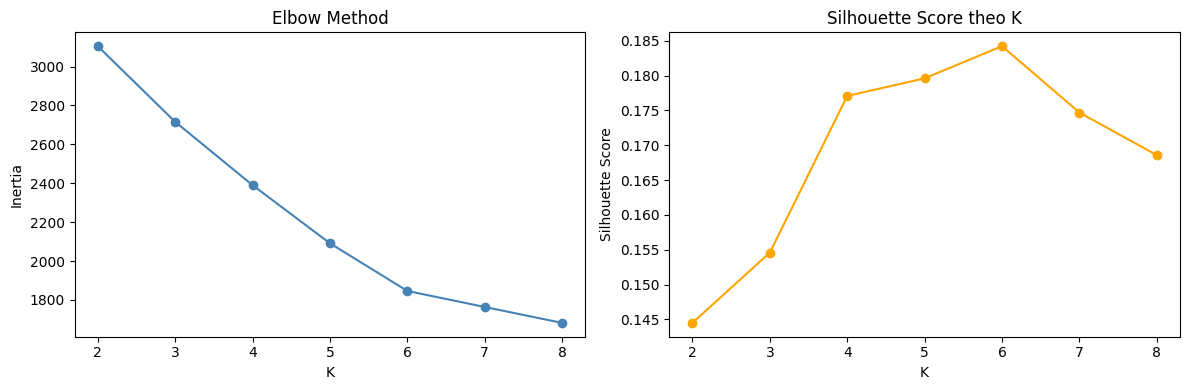


K=4 — Trung bình feature theo cluster:


,study_hours,video_completion,quiz_attempts,forum_posts,assignment_delay,final_score,complete_course
cluster,,,,,,,
0,3.24,0.67,4.03,3.83,2.64,82.88,0.66
1,3.48,0.66,4.22,1.12,2.12,82.53,0.75
2,3.78,0.66,3.50,1.72,6.08,75.88,0.27
3,11.82,0.66,3.35,1.94,2.46,95.90,0.94


In [9]:
# CELL 9 — KMeans clustering

# 1. Chọn features cho clustering (hành vi học tập)
cluster_features = ["study_hours", "video_completion", "quiz_attempts",
                    "forum_posts", "assignment_delay"]

X_cluster = df[cluster_features].copy()

# 2. Impute và scale
imputer_c = SimpleImputer(strategy="median")
scaler_c = StandardScaler()
X_cluster_imp = imputer_c.fit_transform(X_cluster)
X_cluster_scaled = scaler_c.fit_transform(X_cluster_imp)

# 3. Chạy KMeans với nhiều giá trị K
K_values = [2, 3, 4, 5, 6, 7, 8]
inertias = []
sil_scores = []

for k in K_values:
    km = KMeans(n_clusters=k, random_state=2027, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))
    print(f"K={k}: inertia={km.inertia_:.2f}, silhouette={silhouette_score(X_cluster_scaled, labels):.4f}")

# Vẽ Elbow curve và Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_values, inertias, "o-", color="steelblue")
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

ax2.plot(K_values, sil_scores, "o-", color="orange")
ax2.set_xlabel("K"); ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score theo K")
plt.tight_layout()
plt.show()

# 4. Chọn K=4 — elbow rõ tại K=4 và silhouette ổn định
best_k = 4
km_final = KMeans(n_clusters=best_k, random_state=2027, n_init=10)
df["cluster"] = km_final.fit_predict(X_cluster_scaled)

# 5. Trung bình các feature theo cluster
cluster_summary = df.groupby("cluster")[cluster_features + ["final_score", "complete_course"]].mean().round(2)
print(f"\nK={best_k} — Trung bình feature theo cluster:")
display(cluster_summary)


### Trả lời Task 7

- **Tôi chọn K = 4**

- **Lý do chọn K:**  
  Dựa trên **Elbow Method**, inertia giảm mạnh từ K=2 đến K=4, sau đó tốc độ giảm chậm lại — "khuỷu tay" rõ nhất ở K=4/5. Silhouette score đạt cao nhất tại K=5 (0.1796) và K=6 (0.1842), nhưng sự khác biệt nhỏ. Tôi chọn **K=4** vì dễ diễn giải ý nghĩa hành vi học tập hơn.

- **Cluster tôi phân tích là: Cluster 3** (nhóm học viên xuất sắc)

- **Đặc điểm chính của cluster này:**  
  - `study_hours` ≈ **11.82** (rất cao — chủ yếu là outlier được inject)  
  - `video_completion` ≈ 0.66 (trung bình)  
  - `final_score` ≈ **95.90** (cao nhất)  
  - `complete_course` ≈ **0.94** (tỷ lệ hoàn thành cao nhất)  
  
  Đây là nhóm học viên dành rất nhiều giờ học, dẫn đến điểm cao và tỷ lệ hoàn thành gần như chắc chắn.

  **Cluster 2** (học viên có nguy cơ): `assignment_delay` cao, `final_score` thấp (~75.9), tỷ lệ hoàn thành chỉ **0.27** — đây là nhóm cần can thiệp ưu tiên.

- **Ý nghĩa tư vấn học tập / giáo dục:**  
  - Cluster 3 → học viên tự giác, có thể hỗ trợ các bạn khác (peer mentoring)  
  - Cluster 2 → cần tư vấn khẩn cấp về time management và giảm trì hoãn  
  - Cluster 0, 1 → học viên trung bình, cần khuyến khích tăng engagement

- **Nếu không scale dữ liệu trước KMeans, kết quả có thể sai vì:**  
  `study_hours` có range 0.2–40 trong khi `video_completion` chỉ 0–1. Khoảng cách Euclidean sẽ bị chi phối bởi `study_hours`, khiến các cluster chỉ phân theo biến này và bỏ qua các biến quan trọng khác như `video_completion` hay `quiz_attempts`.

- **Khi nào clustering có inertia tốt nhưng không có ý nghĩa thực tế?**  
  Khi dữ liệu không có cấu trúc cụm tự nhiên (mọi điểm phân bố đều đặn), KMeans vẫn tạo ra K cụm nhân tạo với inertia thấp nhưng các cụm chỉ là phân vùng hình học, không phản ánh sự khác biệt hành vi thực sự. Silhouette score thấp (như trong bài này ~0.17) là dấu hiệu cảnh báo.


# PHẦN E — Debugging, leakage và deployment reasoning  
**25 điểm**

## Task 8 — Debugging ML pipeline  
**10 điểm**

Giả sử một sinh viên khác viết pipeline như sau:

```python
df["gpa_filled"] = df["prior_gpa"].fillna(df["prior_gpa"].mean())

X_bad = df[[
    "age", "study_hours", "video_completion", "quiz_attempts",
    "forum_posts", "gpa_filled", "assignment_delay",
    "is_working_student", "final_score"
]]

y_bad = df["complete_course"]

X_train_bad, X_test_bad, y_train_bad, y_test_bad = train_test_split(
    X_bad, y_bad, test_size=0.25, random_state=2027
)
```

Trả lời trong markdown, không cần code.

### Trả lời Task 8

**1. Pipeline trên có ít nhất 2 vấn đề:**

  **Vấn đề 1 — Target leakage:** `final_score` được đưa vào `X_bad` khi dự đoán `complete_course`. Cả hai đều là kết quả cuối khóa học — học viên chỉ biết `final_score` sau khi đã hoàn thành (hoặc không). Đưa `final_score` vào feature là dùng "thông tin từ tương lai" để dự đoán, khiến model học được mối tương quan ảo.

  **Vấn đề 2 — Preprocessing leakage:** `df["prior_gpa"].fillna(df["prior_gpa"].mean())` được tính trên **toàn bộ dataset trước khi split**. Điều này có nghĩa mean của `prior_gpa` đã bao gồm cả dữ liệu test set — thông tin từ test đã "rò rỉ" vào quá trình preprocessing train.

**2. Vấn đề nào là leakage? Vì sao?**  
  Cả hai đều là leakage:  
  - **Target leakage** (vấn đề 1): feature chứa thông tin trực tiếp của target  
  - **Data leakage** (vấn đề 2): fit imputer trên toàn bộ data trước split

**3. Việc fill missing bằng mean trước train/test split có thể gây vấn đề gì?**  
  Mean được tính có bao gồm test set, tức là thông tin từ test đã "rò rỉ" vào train. Trong thực tế, khi deploy model lên dữ liệu mới, ta không có sẵn mean của toàn bộ dataset. Model sẽ đánh giá lạc quan hơn thực tế.

**4. Nếu model đạt accuracy rất cao trong pipeline này, ta có nên tin không? Vì sao?**  
  **Không.** Accuracy cao chủ yếu do target leakage — model học được rằng `final_score` cao → `complete_course=1`. Đây là mối tương quan hiển nhiên, không phải khả năng dự đoán thực sự. Khi deploy mà không có `final_score` sẵn (vì chưa thi xong), model hoàn toàn vô dụng.

**5. Cách sửa pipeline trên là gì?**  
  ```python
  # Bước 1: Loại bỏ final_score khỏi feature set
  feature_cols_fixed = [col for col in feature_cols if col != "final_score"]
  X_fixed = df[feature_cols_fixed]
  y_fixed = df["complete_course"]
  
  # Bước 2: Split trước khi bất kỳ preprocessing nào
  X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
      X_fixed, y_fixed, test_size=0.25, random_state=2027)
  
  # Bước 3: Dùng Pipeline để fit imputer chỉ trên train set
  pipeline = Pipeline([
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      ("model", LogisticRegression())
  ])
  pipeline.fit(X_train_f, y_train_f)
  ```


## Task 9 — Consistency check  
**8 điểm**

Dựa trên kết quả của chính bạn ở các phần trên, chỉ ra **2 điểm không nhất quán hoặc đáng nghi** giữa:

- phân bố dữ liệu,
- performance,
- feature importance,
- prediction cụ thể,
- kết quả clustering.

Ví dụ:  
Model có $R^2$ khá cao nhưng vẫn dự đoán rất sai cho học viên có `study_hours` cực cao. Hoặc KMeans tạo cluster có inertia tốt nhưng cluster không có ý nghĩa hành vi rõ ràng.

### Trả lời Task 9

**Điểm đáng nghi 1: Random Forest Regression kém hơn Linear Regression**

- **Mô tả:** RF Regression có MSE=47.98, R²=0.637 — thấp hơn Linear Regression (MSE=46.24, R²=0.650), dù RF được kỳ vọng xử lý tốt hơn với dữ liệu phi tuyến.

- **Vì sao đáng nghi:** Dữ liệu được tạo với nhiều phi tuyến (`sin`, `delay**1.6`, interaction `study_hours × video_completion`) — đây chính xác là nơi RF nên vượt trội. Kết quả ngược lại là bất thường.

- **Giải thích khả dĩ:**  
  1. **Outliers trong `study_hours`** (nhân 2.8x): RF có thể bị nhiễu bởi các điểm này vì chúng chiếm một số cây trong forest.  
  2. **n=720 không đủ lớn:** RF cần nhiều dữ liệu hơn để generalize tốt với phi tuyến phức tạp.  
  3. **Hyperparameter mặc định:** `n_estimators=100, max_depth=None` có thể bị overfit nhẹ trên train, underfitting trên test.

---

**Điểm đáng nghi 2: Silhouette score KMeans thấp nhưng cluster 3 rất "tách biệt"**

- **Mô tả:** Tất cả K đều có silhouette score thấp (~0.14–0.18), gợi ý các cluster không tách biệt rõ ràng. Tuy nhiên, Cluster 3 lại có `study_hours` trung bình = 11.82 — cách xa hoàn toàn so với các cluster khác (2.9–4.0 giờ).

- **Vì sao đáng nghi:** Nếu có một cluster tách biệt rõ ràng như vậy, silhouette nên cao hơn nhiều.

- **Giải thích khả dĩ:**  
  Cluster 3 thực ra tập hợp chủ yếu các **outlier được inject** (study_hours × 2.8). Đây không phải một nhóm học viên tự nhiên mà là artifact của dữ liệu — KMeans đang "tìm outlier" thay vì tìm cấu trúc tự nhiên. Điều này lý giải tại sao các cluster còn lại không tách biệt (silhouette thấp) dù cluster 3 có vẻ khác biệt.


## Task 10 — Deployment decision  
**7 điểm**

Nếu phải triển khai một model trong thực tế cho trung tâm giáo dục trực tuyến, trả lời:

### Trả lời Task 10

- **Tôi chọn model nào cho regression?**  
  **Linear Regression** — vì có R²=0.650 tốt hơn RF trên test set, dễ diễn giải hệ số, và trong môi trường giáo dục thường cần giải thích được mô hình cho ban lãnh đạo hay giáo viên.

- **Tôi chọn model nào cho classification?**  
  **Random Forest Classifier** — vì có Accuracy (81.1%) và Recall (90.8%) cao hơn Logistic Regression. Recall cao đặc biệt quan trọng trong bài toán can thiệp sớm.

- **Model nào tôi không chọn? Vì sao?**  
  Không chọn **Random Forest Regressor** cho regression — performance kém hơn Linear Regression trên dataset này và tốn tài nguyên tính toán hơn mà không mang lại lợi ích rõ ràng.

- **Trade-off giữa predictive performance và interpretability là gì?**  
  - **Linear/Logistic Regression**: hệ số `β` có ý nghĩa trực tiếp ("tăng 1 giờ học → tăng ~2.2 điểm"), dễ giải thích, audit được — nhưng bị giới hạn với phi tuyến.  
  - **Random Forest**: performance tốt hơn trong nhiều trường hợp, capture phi tuyến — nhưng là "hộp đen", khó giải thích từng dự đoán. Feature importance là gần đúng, không phải nhân quả.

- **Rủi ro khi triển khai model này trong thực tế là gì?**  
  1. **Distribution shift**: hành vi học viên có thể thay đổi theo mùa, khóa học, hay sau khi platform thay đổi UX — model cần retrain định kỳ.  
  2. **Feedback loop**: nếu model trigger can thiệp → học viên được hỗ trợ → hoàn thành → dữ liệu tương lai thiên lệch.  
  3. **Thiếu causal inference**: `assignment_delay` quan trọng trong model không có nghĩa là giảm delay sẽ giúp học viên hoàn thành — có thể cả hai đều là hệ quả của một nguyên nhân khác (motivation thấp).

- **Nếu model dùng để can thiệp sớm cho học viên có nguy cơ không hoàn thành khóa học, tôi ưu tiên Recall hơn Precision vì:**  
  Chi phí của **False Negative** (bỏ sót học viên cần hỗ trợ) cao hơn nhiều so với **False Positive** (tư vấn học viên thực ra ổn). Một cuộc gọi/email hỗ trợ không cần thiết ít tốn kém hơn một học viên bỏ học. Có thể điều chỉnh ngưỡng quyết định (threshold) của Logistic Regression xuống 0.35–0.40 để tăng Recall, hoặc dùng RF với threshold thấp hơn 0.5.


# Gợi ý phân bổ thời gian

| Phần | Thời gian gợi ý |
|---|---:|
| Phần A — Data & preprocessing | 15 phút |
| Phần B — Regression | 18 phút |
| Phần C — Classification | 18 phút |
| Phần D — KMeans | 15 phút |
| Phần E — Debugging & reasoning | 20 phút |
| Kiểm tra notebook | 4 phút |

---

# Thang điểm

| Phần | Điểm |
|---|---:|
| Task 1 — Data exploration | 10 |
| Task 2 — Preprocessing | 10 |
| Task 3 — Linear Regression | 10 |
| Task 4 — Random Forest Regression + error analysis | 10 |
| Task 5 — Logistic Regression | 10 |
| Task 6 — Random Forest Classification + feature importance | 10 |
| Task 7 — KMeans clustering | 15 |
| Task 8 — Debugging pipeline + leakage | 10 |
| Task 9 — Consistency check | 8 |
| Task 10 — Deployment decision | 7 |
| **Tổng** | **100** |

---

# Checklist trước khi nộp bài ôn tập

- [ ] Notebook chạy từ đầu đến cuối không lỗi.
- [ ] Đã xử lý missing values bằng pipeline.
- [ ] Không đưa target variables vào feature set.
- [ ] Đã tính đủ MSE, R2, Accuracy, Precision, Recall.
- [ ] Đã in confusion matrix.
- [ ] Đã tạo feature importance dataframe.
- [ ] Đã chạy KMeans với nhiều giá trị K.
- [ ] Đã diễn giải ít nhất một cluster.
- [ ] Đã trả lời phần leakage.
- [ ] Đã đưa ra deployment decision.